## Wykrywanie naczyń dna siatkówki oka

#### Wymagania obowiązkowe

- Importowane biblioteki:


In [10]:
import cv2
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from skimage.filters import frangi
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score
from imblearn.metrics import specificity_score, geometric_mean_score


- Pobranie plików z oryginalnymi zdjęciami, maskami eksperckimi oraz plikami 'Field of View':

In [2]:
def get_original_images(i=1):
    directory_image = r"database\images"    #obrazy oryginalne
    directory_mask = r"database\manual1"    #maski eksperckie
    directory_fov = r"database\mask"        #pliki Field Of View

    #pobranie oryginalnych obrazów
    image_name = f"{i:02}_dr.JPG"       
    image_file = os.path.join(directory_image, image_name)
    if image_name.lower().endswith('.jpg') or image_name.lower().endswith('.JPG'):
        original_image = Image.open(image_file)
        image_np = np.array(original_image) 
    
    #pobranie masek eksperckich
    mask_name = f"{i:02}_dr.tif" 
    mask_file = os.path.join(directory_mask, mask_name)
    if mask_file.lower().endswith('.tif'):
        original_mask = Image.open(mask_file)
        mask_np = np.array(original_mask)
        bw_mask_np = np.where(mask_np > 128, 255, 0).astype(np.uint8)

    #pobranie plików Field of View
    fov_name = f"{i:02}_dr_mask.tif" 
    fov_path = os.path.join(directory_fov, fov_name)
    if fov_name.lower().endswith('.tif'):
        original_fov = Image.open(fov_path)
        fov_np = np.array(original_fov)
        bw_fov_np = np.where(fov_np > 128, 255, 0).astype(np.uint8)
    
    return image_np, bw_mask_np, bw_fov_np

- Przedstawienie oryginalnego zdjęcia:

In [3]:
def present_image(original_image, title): 
    plt.figure(figsize=(6, 6))
    plt.imshow(original_image)
    plt.title(title)
    plt.axis('off')
    plt.show()

- Wstępne przetworzenie obrazu:

In [13]:
def preprocess_image(original_image):   
    #wyodrębnienie kanałów RGB
    R_channel = original_image[..., 0]
    G_channel = original_image[..., 1]
    B_channel = original_image[..., 2]
    
    #wyliczenie średniej ważonej kanałów RGB
    brightness = R_channel*0.33 + G_channel*0.33 + B_channel*0.33 

    #tworzenie maski progowej - piksele jaśniejsze niż 30% maksymalnej jasności są oznaczane jako True
    new_mask = brightness > np.max(brightness) * 0.3
    new_mask = 1 * new_mask.astype(np.uint8)
    new_mask = cv2.erode(new_mask, np.ones((3,3), np.uint8), iterations=1)

    #poprwienie kontrastu na oryginalnym obrazie
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    image = original_image.copy()
    
    for i in range(3):
        image[..., i] = clahe.apply(original_image[..., i])

    image *= new_mask[..., np.newaxis]

    return new_mask, image

- Właściwe i końcowe przetworzenie obrazu:

In [5]:
def main_process_image(image, mask):
    #Zastosowanie filtru Frangi'ego na wstępnie przetworzonym obrazie
    image_frangi = frangi(image[..., 1]) 
    #normalizacja obrazu Frangiego od zakresu [0,1] 
    image_frangi = image_frangi / image_frangi.max()
    #pierwiastkowanie - uwydatnienie słąbych naczyń
    image_frangi = np.power(image_frangi, 0.5)

    #próg binarny - wszystko powyżej 0.01 możę zostać uznane za potencjalne naczynia
    vessel_mask = (image_frangi > 0.01).astype(np.uint8)

    #erozja - usunięcie szumu
    vessel_mask = cv2.erode(vessel_mask, np.ones((3, 3), np.uint8), iterations=1)

    #wyszukiwanie połączonych obiektów - komponentów
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(vessel_mask, connectivity=8)
    
    #odfiltrowanie małych komponentów (mniejsych niż 200 pikseli)
    min_size = 200
    filtered = np.zeros_like(labels, dtype=np.uint8)
    for i in range(1, num_labels):  
        if stats[i, cv2.CC_STAT_AREA] >= min_size:
            filtered[labels == i] = 1
    #maska końcowa to iloczyn maski wejściowej i przefiltrowanych naczyń
    generated_mask = (mask * filtered) * 255
    
    return generated_mask.astype(np.uint8)


In [6]:
def ensure_rgba(image):
    array = np.array(image)
    if array.ndim == 2:
        array = np.stack([array]*3, axis=-1)
    if array.shape[2] == 3: 
        alpha = np.full((array.shape[0], array.shape[1], 1), 255, dtype=np.uint8)
        array = np.concatenate((array, alpha), axis=2)
    return array

- Przedstawienie maski wygenerowanej i eksperckiej oznaczonej na oryginalnym obrazie:

In [7]:
def mask_on_original_image(original_image, mask):
    
    mask_array = ensure_rgba(mask)
    original_array = ensure_rgba(original_image)

    white = [255, 255, 255]
    bright_green = [0, 255, 0, 255]

    green_mask = np.all(mask_array[:, :, :3] == white, axis=2)
    green_layer = np.zeros_like(mask_array)
    green_layer[green_mask] = bright_green
    green_image = Image.fromarray(green_layer.astype(np.uint8))

    original_image = Image.fromarray(original_array).resize(green_image.size)
    combined = Image.alpha_composite(original_image, green_image)

    return combined

- Zastosowanie 'Field Of View' na wygenerowanej masce:

In [8]:
def strip_frame(fov_image, mask):
    # Konwersja RGB → grayscale, jeśli potrzeba
    if fov_image.ndim == 3 and fov_image.shape[2] == 3:
        fov_image = np.mean(fov_image, axis=2)

    # Sprawdzenie zgodności wymiarów
    if mask.shape != fov_image.shape:
        raise ValueError(f"Rozmiary masek się nie zgadzają: {mask.shape} vs {fov_image.shape}")

    # Ustaw piksele na 0 tam, gdzie ramka (mask2) jest czarna
    modified_mask = mask.copy()
    modified_mask[fov_image == 0] = 0

    return modified_mask

- Przedstawienie maski wygenerowanej z maską ekspercką:

In [9]:

def compare_masks(original_mask, generated_mask):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(generated_mask, cmap='gray')
    plt.title("Maska wygenerowana")
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(original_mask, cmap='gray')
    plt.title("Maska ekspercka")
    plt.axis('off')
    plt.show()

- Ocena skuteczności algorytmu:

In [10]:
def get_algorithm_quality(original_mask, img):
    gt = (np.array(original_mask) > 0).astype(np.uint8)
    pred = np.array(img)
    if pred.ndim == 3:
        pred = pred[:, :, 0]
    pred = (pred > 0).astype(np.uint8)

    if gt.shape != pred.shape:
        h, w = gt.shape
        pred_resized = Image.fromarray(pred * 255).resize((w, h), Image.NEAREST)
        pred = (np.array(pred_resized) > 0).astype(np.uint8)

    gt_flat = gt.flatten()
    pred_flat = pred.flatten()

    # Macierz pomyłek
    tn, fp, fn, tp = confusion_matrix(gt_flat, pred_flat, labels=[0, 1]).ravel()

    #Trafność
    acc = accuracy_score(gt_flat, pred_flat)
    #Czułość
    sensitivity = recall_score(gt_flat, pred_flat, pos_label=1)
    #Swoistość
    specificity = specificity_score(gt_flat, pred_flat, pos_label=1)
    #Średnia geometryczna czułości
    geometric_mean = geometric_mean_score(gt_flat, pred_flat, average='binary')

    return {
        "True Positive": tp,
        "True Negative": tn,
        "False Positive": fp,
        "False Negative": fn,
        "Trafność": acc,
        "Czułość": sensitivity,
        "Swoistość": specificity,
        "Średnia geometryczna czułości": geometric_mean
    }


1-ty obraz


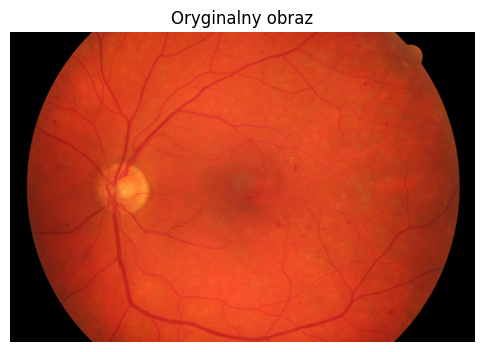

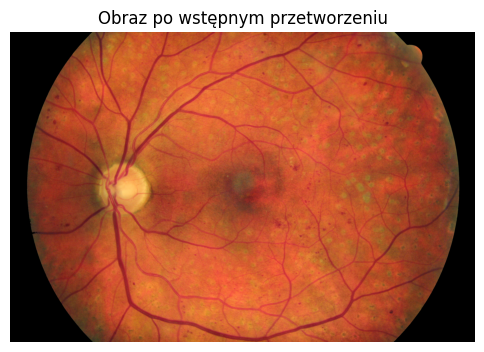

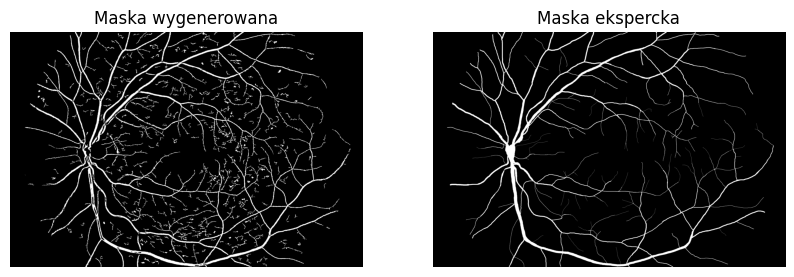

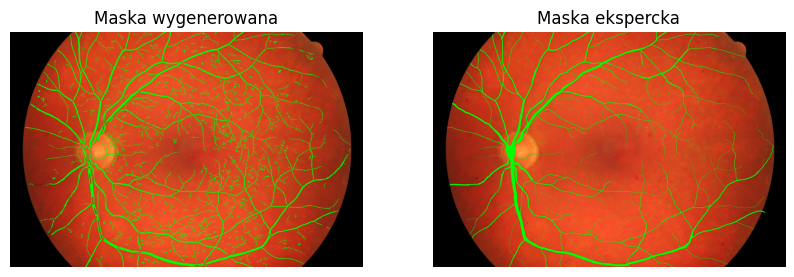

Macierz pomyłek
True Positive: 302108
True Negative: 7441332
False Positive: 327730
False Negative: 114174
Trafność: 0.9460
Czułość: 0.7257
Swoistość: 0.9578
Średnia geometryczna czułości: 0.8337
2-ty obraz


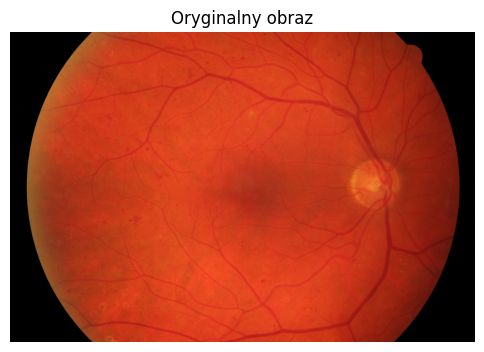

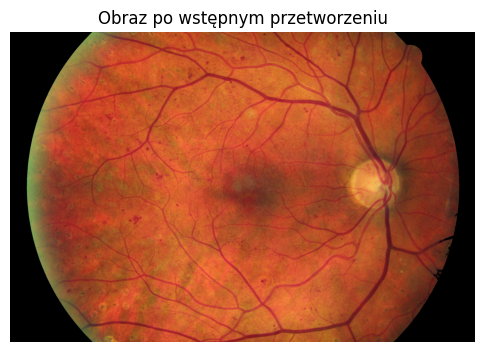

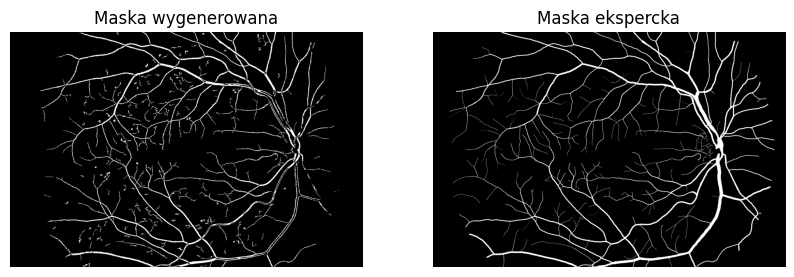

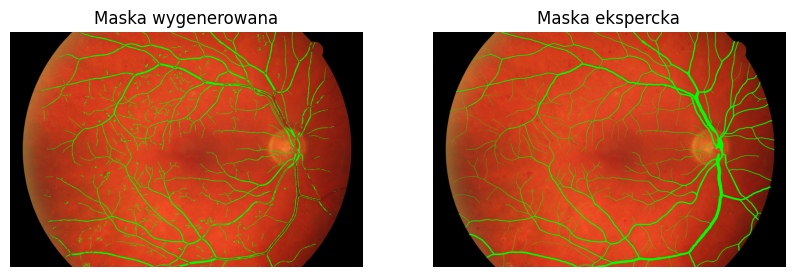

Macierz pomyłek
True Positive: 317756
True Negative: 7509094
False Positive: 154372
False Negative: 204122
Trafność: 0.9562
Czułość: 0.6089
Swoistość: 0.9799
Średnia geometryczna czułości: 0.7724
3-ty obraz


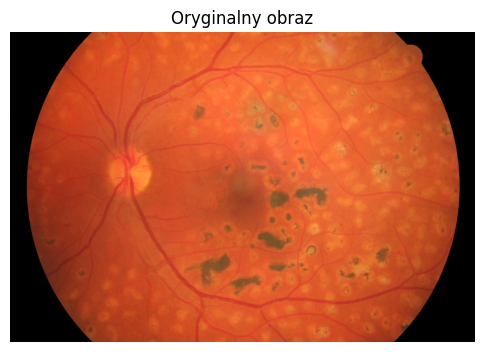

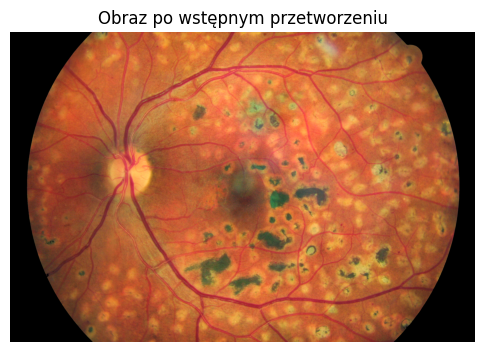

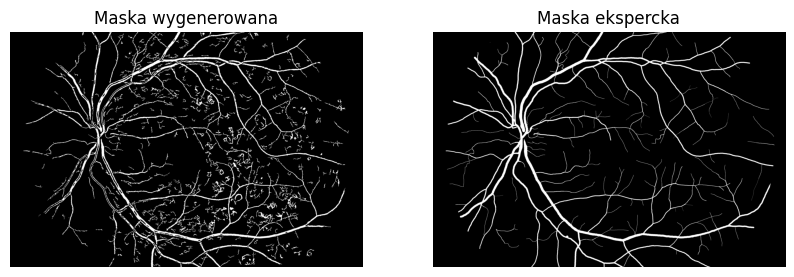

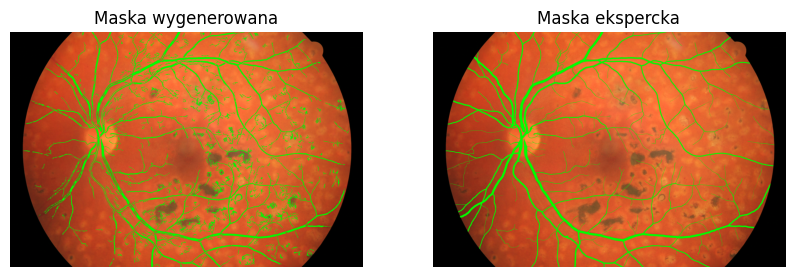

Macierz pomyłek
True Positive: 339478
True Negative: 7380548
False Positive: 310396
False Negative: 154922
Trafność: 0.9432
Czułość: 0.6866
Swoistość: 0.9596
Średnia geometryczna czułości: 0.8117
4-ty obraz


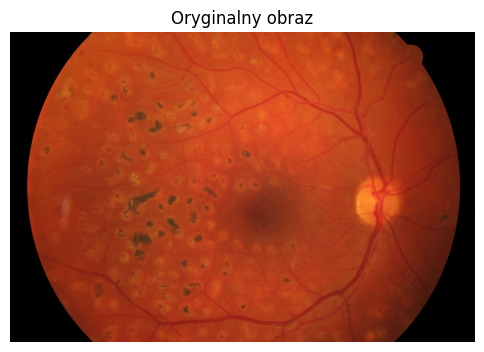

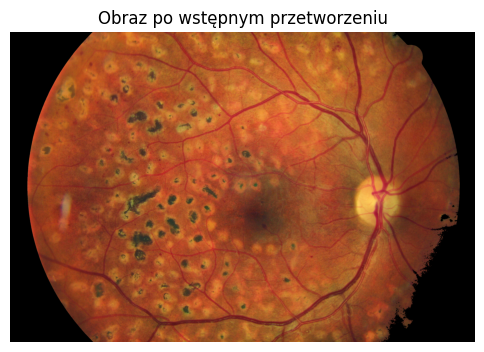

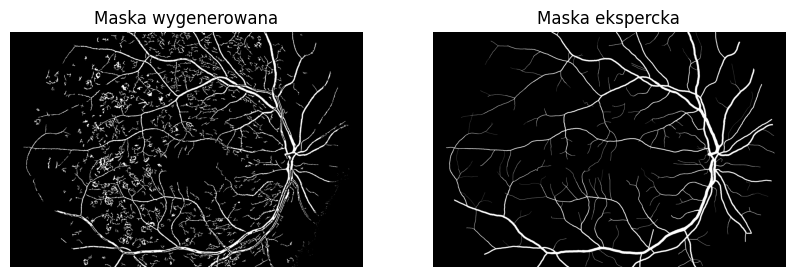

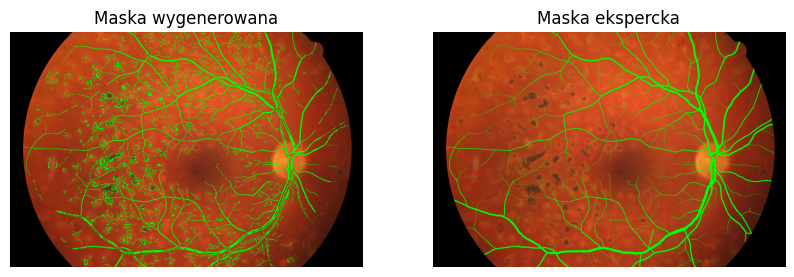

Macierz pomyłek
True Positive: 310846
True Negative: 7347097
False Positive: 376068
False Negative: 151333
Trafność: 0.9356
Czułość: 0.6726
Swoistość: 0.9513
Średnia geometryczna czułości: 0.7999
5-ty obraz


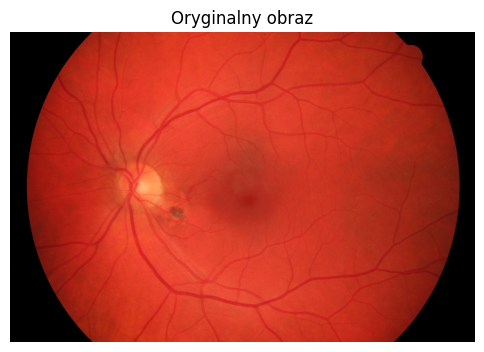

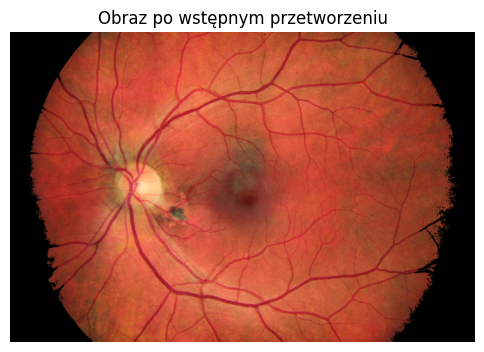

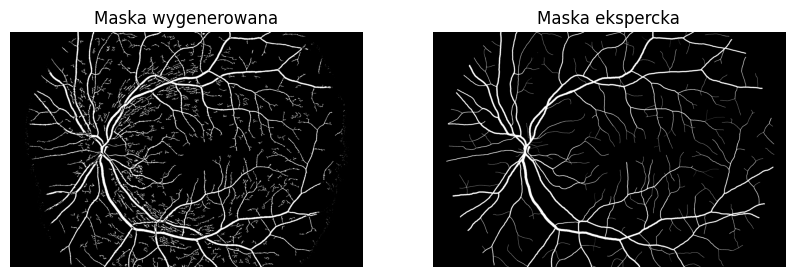

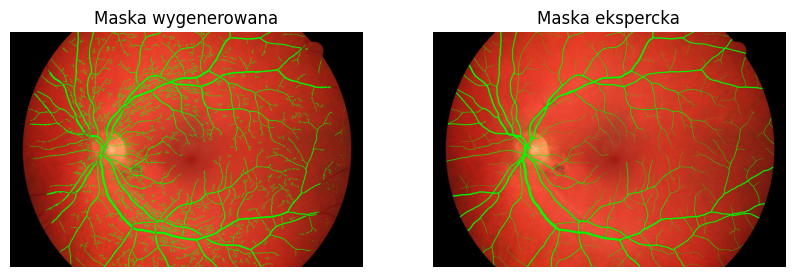

Macierz pomyłek
True Positive: 401296
True Negative: 7338790
False Positive: 337576
False Negative: 107682
Trafność: 0.9456
Czułość: 0.7884
Swoistość: 0.9560
Średnia geometryczna czułości: 0.8682


In [11]:
def main_first_step():
    for i in range(1,6):
        print("===============================================")
        print(f"{i}-ty obraz")
        print("===============================================")
        
        image_np, bw_mask_np, bw_fov_np = get_original_images(i)
        present_image(image_np, "Oryginalny obraz")
        generated_mask, image = preprocess_image(image_np)
        present_image(image, "Obraz po wstępnym przetworzeniu")
        generated_mask = main_process_image(image, generated_mask)
        generated_mask = strip_frame(bw_fov_np, generated_mask)
        generated_mask_on_image = mask_on_original_image(image_np, generated_mask)
        original_mask_on_image = mask_on_original_image(image_np, bw_mask_np)
        compare_masks(bw_mask_np, generated_mask)
        compare_masks(original_mask_on_image, generated_mask_on_image)
        quality=get_algorithm_quality(bw_mask_np, generated_mask)

        #Przedstawienie oceny skuteczności
        print("Macierz pomyłek")
        for k, v in quality.items():
            print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

        
main_first_step()

#### Etap drugi (na 4)


- Zastosowane biblioteki:

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from imblearn.under_sampling import RandomUnderSampler

- Zebranie oryginalnych obrazów, mask eksperckich oraz plików 'Field Of View'. Podział ich na grupy testowe oraz treningowe. Oryginalne obrazy zostały także wstępnie przetworzone funkcją z pierwszego etapu.

In [13]:
def get_original_images(n=5):
    directory = r"database\images"
    #Pobranie obrazów oryginalnych obrazów:
    original_images_tests = []
    for i in range(n,15):
        image= f"{i:02}_dr.JPG"
        jpg_file = os.path.join(directory, image)
        if image.lower().endswith('.jpg') or image.lower().endswith('.JPG'):
            img = Image.open(jpg_file)
            img_np = np.array(img) 
            #Przeprowadzenie wstępnego przetworzenia obrazu
            _, img_np = preprocess_image(img_np)
        original_images_tests.append(img_np)

    original_images = []
    for i in range(1,n):
        image= f"{i:02}_dr.JPG"
        jpg_file = os.path.join(directory, image)
        if image.lower().endswith('.jpg') or image.lower().endswith('.JPG'):
            img = Image.open(jpg_file)
            img_np = np.array(img) 
            #Przeprowadzenie wstępnego przetworzenia obrazu
            _, img_np = preprocess_image(img_np)
        original_images.append(img_np)
    
    #Pobranie mask eksperckich
    mask_images = []
    directory = r"database\manual1"
    for i in range(1, n):
        mask = f"{i:02}_dr.tif" 
        tif_file = os.path.join(directory, mask)
        if mask.lower().endswith('.tif'):
            img = Image.open(tif_file)
            img_np = np.array(img)
            #modyfikacja formatu obrazu do czarno-białego
            bw_img_np = np.where(img_np > 128, 255, 0).astype(np.uint8)
            mask_images.append(bw_img_np)

    #Pobranie plików 'Field Of View'
    fov_images_tests = []
    directory = r"database/mask"
    for i in range(n,15):
        fov = f"{i:02}_dr_mask.tif" 
        fov_path = os.path.join(directory, fov)
        if fov.lower().endswith('.tif'):
            img = Image.open(fov_path)
            img_np = np.array(img)
            #modyfikacja formatu obrazu do czarno-białego
            bw_img_np = np.where(img_np > 128, 255, 0).astype(np.uint8)
            fov_images_tests.append(bw_img_np)

    fov_images = []
    for i in range(1,n):
        fov = f"{i:02}_dr_mask.tif" 
        fov_path = os.path.join(directory, fov)
        if fov.lower().endswith('.tif'):
            img = Image.open(fov_path)
            img_np = np.array(img)
            #modyfikacja formatu obrazu do czarno-białego
            bw_img_np = np.where(img_np > 128, 255, 0).astype(np.uint8)
            fov_images.append(bw_img_np)
            
    return original_images, original_images_tests, mask_images, fov_images, fov_images_tests

- Podział obrazów oraz masek eksperckich na wycinki (5x5 pixeli) i wybranie tych, które nie pokrywają się z odpowiednim 'Field Of View':

In [14]:
def split_into_grid(original_images, mask_images, fov_images):
    #wycinki wstępnie przetworzonych obrazów
    grids = []
    #wycinki maski eksperckiej
    masks = []

    for i in range(len(original_images)):
        height, width = original_images[i].shape[:2]
        for _ in range(50000):
            while True:
                #wylosowanie randomowych wartości identyfikujących lokalizację piksela
                rand_y = np.random.randint(2, height - 2)
                rand_x = np.random.randint(2, width - 2)
                #uformowanie wycinka na jej podstawie na pliku "field of view"
                fov_grid = fov_images[i][rand_y - 2:rand_y + 3, rand_x - 2:rand_x + 3]
                #weryfikacja, czy jakikolwiek piksel zawiera kolor czarny
                if fov_grid.ndim == 3:
                    is_black_in_grid = np.any(np.all(fov_grid == 0, axis=-1))
                else:
                    is_black_in_grid = np.any(fov_grid == 0)
                #dodanie do listy wycinka, który nie zawiera czarnego piksela w "field of view"
                if not is_black_in_grid:
                    original_grid = original_images[i][rand_y - 2:rand_y + 3, rand_x - 2:rand_x + 3]
                    mask_grid = mask_images[i][rand_y - 2:rand_y + 3, rand_x - 2:rand_x + 3]
                    grids.append(original_grid)
                    masks.append(mask_grid)
                    break 
    return grids, masks

- Zebranie dla wycinków wariancji kolorów, momentów centralnych i momentów Hu, a następnie na ich podstawie przygotowanie listy danych niezbędnych do budowy klasyfikatora:

In [15]:
def get_data_from_grids(grids):
    X_dataset = []

    for grid in grids:
        X_grid_dataset = []
        for channel in range(2):

            channel = grid[:, :, channel]
            channel_uint8 = (channel * 255).astype(np.uint8) if channel.max() <= 1 else channel.astype(np.uint8)
            
            #momenty Hu
            moments = cv2.moments(channel_uint8)
            hu_moments = cv2.HuMoments(moments).flatten()
            #Momenty centralne
            central_moments = [
                moments['mu20'], moments['mu11'], moments['mu02'],
                moments['mu30'], moments['mu21'], moments['mu12'], moments['mu03']
            ]

            #Obliczenie cech charakterystycznych
            #wariancja
            variance = np.var(channel)
            #średnia
            mean = np.mean(channel)
            #odchylenie standardowe
            stddev = np.std(channel)
            #maksimum
            max_val = np.max(channel)
            #minimum
            min_val = np.min(channel)
            #Obliczenie skośności rozkładu
            skewness = ((channel - mean)**3).mean() / (stddev**3 + 1e-8)
            
            channel_dataset = [variance, mean, stddev, skewness, max_val, min_val]
            channel_dataset.extend(hu_moments.tolist())
            channel_dataset.extend(central_moments)

            X_grid_dataset.extend(channel_dataset)

        X_dataset.append(X_grid_dataset)

    return np.array(X_dataset)

- Pobranie informacji na podstawie wycików maski eksperckiej o wartości środkowego piksela.
1 odpowiada obecności naczynia krwionośnego, 0 jego braku.
Funkcja tworzy drugą listę niezbędną do stworzenia klasyfikatora:

In [16]:
def get_mask_value(masks):
    mask_colours = []
    for mask in masks:
        middle_value = mask[2,2]
        if middle_value == 255:
            mask_colours.append(1)  #biały kolor - obecne naczynie krwionośne
        elif middle_value == 0:
            mask_colours.append(0)  #czarny kolor
        else: 
            print("Zły format piksela")
    return mask_colours

- Zastosowanie klasyfikatora z wykorzystaniem wycinków wstępnie przetworzonych obrazów oryginalnych i masek eksperckich:

In [17]:
def get_model(masks, grids):
    #Etykiety z maski eksperckiej
    Y_values = np.array(get_mask_value(masks))
    #Wartości określające wycinki obrazów
    X_values = np.array(get_data_from_grids(grids))

    #losowe usunięcie przykładów z klasy dominującej, aby zrównoważyć zbiór
    rus = RandomUnderSampler(sampling_strategy=1, random_state=35)
    X_balanced, Y_balanced = rus.fit_resample(X_values, Y_values)

    #Podział danych na treningowe i testowe
    X_train, X_test, Y_train, Y_test = train_test_split(
        X_balanced, Y_balanced, test_size=0.2, random_state=35, stratify=Y_balanced)

    #Stworzenie klasyfikatora ze stoma drzewami
    clf = RandomForestClassifier(n_estimators=100, random_state=35)
    clf.fit(X_train, Y_train)

    #Predykcja  modelu na zbiorze testowym
    Y_pred = clf.predict(X_test)
    
    #Macierz pomyłek
    tn, fp, fn, tp = confusion_matrix(Y_test, Y_pred).ravel()
    #Trafność
    acc = accuracy_score(Y_test, Y_pred)
    #Czułość
    sensitivity = recall_score(Y_test, Y_pred)  
    #Swoistość
    specificity = specificity_score(Y_test, Y_pred)
    #Średnia geometryczna czułości
    geometric_mean = geometric_mean_score(Y_test, Y_pred)

    results = {
        "True Positive": tp,
        "True Negative": tn,
        "False Positive": fp,
        "False Negative": fn,
        "Trafność": acc,
        "Czułość": sensitivity,
        "Swoistość": specificity,
        "Średnia geometryczna czułości": geometric_mean
    }

    print("Macierz pomyłek")
    for k, v in results.items():
        print(f"{k}: {v}")

    return clf

- Przedstwienie wyników działania klasyfikatora:

In [20]:
def visual_test_second_step(model, images_tests, fov_test):
    
    if isinstance(images_tests[1], tuple):
        image = images_tests[1][0]
    else:
        image = images_tests[1]

    if isinstance(fov_test[1], tuple):
        fov = fov_test[1][0]
    else:
        fov = fov_test[1]

    grid_test = []
    positions = []
    height, width = image.shape[:2]
    img_copy = image.copy()

    if len(img_copy.shape) == 2 or img_copy.shape[2] == 1:
        img_copy = cv2.cvtColor(img_copy, cv2.COLOR_GRAY2BGR)

    for y in range(2, height - 2):
        for x in range(2, width - 2):
            fov_grid = fov[y - 2:y + 3, x - 2:x + 3]
            
            if fov_grid.ndim == 3:
                is_black_in_grid = np.any(np.all(fov_grid == 0, axis=-1))
            else:
                is_black_in_grid = np.any(fov_grid == 0)

            if not is_black_in_grid:
                grid_test.append(image[y - 2:y + 3, x - 2:x + 3])
                positions.append((y, x))

    features = get_data_from_grids(grid_test)
    Y_pred = model.predict(np.array(features)).flatten()
    positions = np.array(positions)
    mask_indices = positions[Y_pred == 1]

    if mask_indices.size > 0:
        y_coords = mask_indices[:, 0]
        x_coords = mask_indices[:, 1]
        img_copy[y_coords, x_coords] = [0, 255, 0]

    plt.figure(figsize=(8, 8))
    plt.imshow(img_copy)
    plt.axis('off')
    plt.show()

Macierz pomyłek
True Positive: 2215
True Negative: 2327
False Positive: 387
False Negative: 500
Trafność: 0.8366181617240744
Czułość: 0.8158379373848987
Swoistość: 0.8574060427413412
Średnia geometryczna czułości: 0.836363782938647


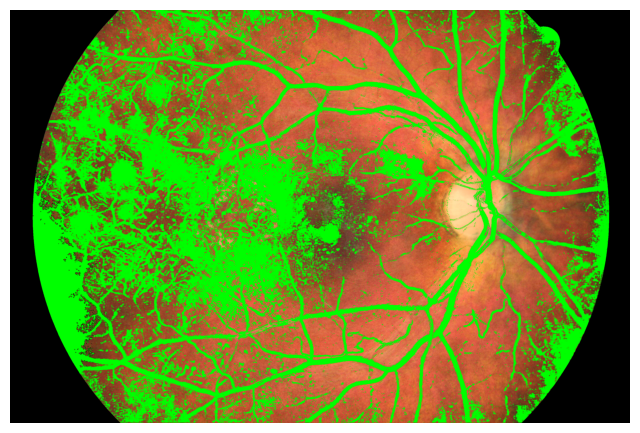

In [21]:
def main_second_step():
    original_images, original_images_tests, mask_images, fov_images, fov_images_test = get_original_images()
    grids, masks = split_into_grid(original_images, mask_images, fov_images)
    model = get_model(masks, grids)
    visual_test_second_step(model, original_images_tests, fov_images_test)
main_second_step() 
    

#### Etap trzeci

- Zaimplementowane biblioteki:

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from monai.networks.nets import UNet
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from skimage import io

In [2]:
def create_dataset(image, window_shape, trim_columns=True):
    height, width = image.shape[:2]
    sub_y, sub_x = window_shape[:2]
    
    if trim_columns:
        trim_width = width // 4
        image = image[:, trim_width:-trim_width]
        width = image.shape[1]
    
    n_x = width // sub_x
    n_y = height // sub_y
    
    remainder_x = width % sub_x
    remainder_y = height % sub_y
    
    start_x = remainder_x // 2
    start_y = remainder_y // 2
    end_x = width - (remainder_x - start_x)
    end_y = height - (remainder_y - start_y)
    
    cropped = image[start_y:end_y, start_x:end_x]
    
    if len(image.shape) == 3:  # Color
        patches = cropped.reshape(n_y, sub_y, n_x, sub_x, image.shape[2])
        patches = patches.transpose(0, 2, 1, 3, 4)
    else:  # Grayscale
        patches = cropped.reshape(n_y, sub_y, n_x, sub_x)
        patches = patches.transpose(0, 2, 1, 3)
        
    return patches.reshape(-1, *window_shape)



In [3]:
def prep_datasets(masks, images, fov):
    images_processed = []
    masks_processed = []
    fov_processed = []
    for image in images:
        img = Image.open(image)
        img_np = np.array(img) 
        if img_np.ndim == 2:
            img_np = np.stack([img_np]*3, axis=-1)
        elif img_np.shape[2] == 1:
            img_np = np.concatenate([img_np]*3, axis=-1)
        _, img_np = preprocess_image(img_np)
        images_processed.append(img_np)
    for mask in masks:
        img = Image.open(mask)
        img_np = np.array(img) 
        bw_img_np = np.where(img_np > 128, 255, 0).astype(np.uint8)
        masks_processed.append(bw_img_np)
    for f in fov:
        img = Image.open(f)
        img_np = np.array(img) 
        bw_img_np = np.where(img_np > 128, 255, 0).astype(np.uint8)
        fov_processed.append(bw_img_np)
    return images_processed, masks_processed, fov_processed


In [4]:
def get_images():
    img_dir = 'database/images'
    mask_dir = 'database/manual1'
    fov_dir = 'database/mask'
    img_paths = sorted([os.path.join(img_dir, f) for f in os.listdir(img_dir)])
    mask_paths = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir)])
    fov_paths = sorted([os.path.join(fov_dir, f) for f in os.listdir(fov_dir)])
    images, masks, fov = prep_datasets(img_paths, mask_paths, fov_paths)
    return images, masks, fov

In [5]:
def train(model, train_loader, device, test_loader, optimizer, loss_fn, metric):
    # Trening
    iter = 100
    best_dice = 0.0
    for i in range(iter):
        model.train()
        train_loss = 0
        for img, mask in train_loader:
            img, mask = img.to(device), mask.to(device)
            optimizer.zero_grad()
            outputs = model(img)
            loss = loss_fn(outputs, mask)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_dice = 0
        with torch.no_grad():
            for img, mask in test_loader:
                img, mask = img.to(device), mask.to(device)
                outputs = torch.sigmoid(model(img))
                metric(outputs, mask)
                val_dice += metric.aggregate().item()
                metric.reset()

        avg_train_loss = train_loss / len(train_loader)
        avg_val_dice = val_dice / len(test_loader)

        if avg_val_dice > best_dice:
            best_dice = avg_val_dice
            torch.save(model.state_dict(), "model.pth")

        print(f"Iteration {i+1}/{iter} :: "
            f"Train Loss: {avg_train_loss:.4f} :: "
            f"Val Dice: {avg_val_dice:.4f}")

In [6]:
def add_model():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = UNet(
        spatial_dims=2,
        in_channels=3,
        out_channels=1,
        channels=(16, 32, 64),  
        strides=(2, 2),      
        num_res_units=2,
    ).to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    metric = DiceMetric(include_background=False, reduction="mean")
    loss_fn = DiceLoss(sigmoid=True)
    return model, loss_fn, metric, optimizer, criterion, device

In [7]:
class DataManager(Dataset):
    def __init__(self, images, masks):
        self.images = np.transpose(images.astype(np.float32) / 255.0, (0, 3, 1, 2))
        self.masks = np.expand_dims(masks.astype(np.float32) / 255.0, axis=1)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return torch.tensor(self.images[idx]), torch.tensor(self.masks[idx])

In [ ]:
def create_model():

    # Pobranie oryginalnych obrazów (i preprocessing), ich masek eksperckich oraz plików 'Field Of View'
    image, masks, fovs = get_images()

    # Ustawienie wszystkich pikseli poza obszarem 'Field Of View' na czarne
    for i in range(len(image)):
        image[i][fovs[i] == 0] = 0

    # Podział na grupę testową i uczącą
    X_train, X_test, Y_train, Y_test = train_test_split(
        image, 
        masks, 
        test_size=0.2, 
        random_state=42,
        shuffle= True
    )

    #Podział zebranych danych do uczenia na wycinki o wymiarze 64x64
    sub_x, sub_y = 64, 64

    #Przygotowanie materiałów do trenowania modelu
    train_patches = []
    train_labels = []
    for i in range(len(X_train)):
        img = X_train[i]
        mask = X_train[i]
    #     img = np.array(Image.open(X_train[i]))
    #     mask = np.array(Image.open(Y_train[i]))
        
        train_patches.append(create_dataset(img, (sub_y, sub_x, 3)))
        train_labels.append(create_dataset(mask, (sub_y, sub_x)))

    train_patches = np.concatenate(train_patches, axis=0)
    train_labels = np.concatenate(train_labels, axis=0)

    test_patches = []
    test_labels = []
    for i in range(len(X_test)):
        # img = np.array(Image.open(X_test[i]))
        # mask = np.array(Image.open(Y_test[i]))
        img = X_test[i]
        mask = X_test[i]
        test_patches.append(create_dataset(img, (sub_y, sub_x, 3)))
        test_labels.append(create_dataset(mask, (sub_y, sub_x)))

    test_patches = np.concatenate(test_patches, axis=0)
    test_labels = np.concatenate(test_labels, axis=0)

    train_dataset = DataManager(train_patches, train_labels)
    test_dataset = DataManager(test_patches, test_labels)


    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

    # Urządzenie
    model, loss_fn, metric, optimizer, _, device = add_model()
    # Trening
    train(model, train_loader, device, test_loader, optimizer, loss_fn, metric)
create_model()

Iteration 1/100 :: Train Loss: 0.9087 :: Val Dice: 0.0000
Iteration 2/100 :: Train Loss: 0.9072 :: Val Dice: 0.0000
Iteration 3/100 :: Train Loss: 0.9071 :: Val Dice: 0.0000
Iteration 4/100 :: Train Loss: 0.9071 :: Val Dice: 0.0002


Percentage of matching pixels: 95.83%


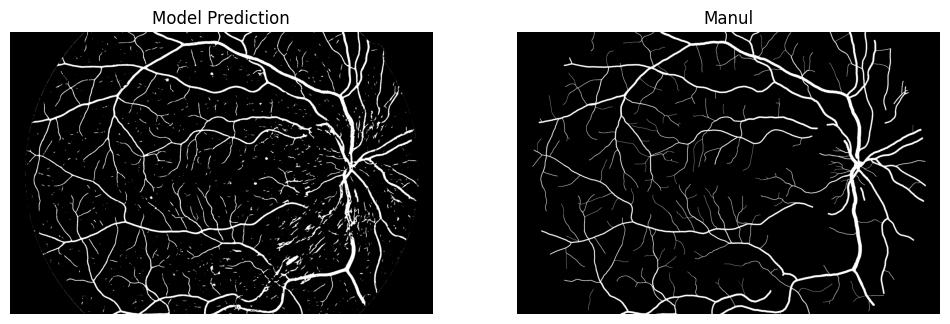

In [7]:

def predict_full_image(model, image, patch_size, overlap, device):
    model.eval()
    h, w = image.shape[:2]
    sub_y, sub_x = patch_size
    stride_y = int(sub_y * (1 - overlap))
    stride_x = int(sub_x * (1 - overlap))
    
    pad_y = (sub_y - h % sub_y) % sub_y
    pad_x = (sub_x - w % sub_x) % sub_x
    image_padded = np.pad(image, ((0, pad_y), (0, pad_x), (0, 0)), mode='reflect')
    
    output = np.zeros((image_padded.shape[0], image_padded.shape[1]))
    counts = np.zeros_like(output) + 1e-7 
    
    with torch.no_grad():
        for y in range(0, image_padded.shape[0] - sub_y + 1, stride_y):
            for x in range(0, image_padded.shape[1] - sub_x + 1, stride_x):
                patch = image_padded[y:y+sub_y, x:x+sub_x]
                patch_tensor = torch.from_numpy(patch).float().permute(2, 0, 1).unsqueeze(0).to(device) / 255.0

                
                pred = torch.sigmoid(model(patch_tensor))
                pred_np = pred.squeeze().cpu().numpy()
                
                output[y:y+sub_y, x:x+sub_x] += pred_np
                counts[y:y+sub_y, x:x+sub_x] += 1
    
    output = np.divide(output, counts, 
                      out=np.zeros_like(output), 
                      where=counts>0.5) 
    
    return output[:h, :w]

def display_greyscale_images(image_1, image_2 = None, title_1: str | None = None, title_2: str | None = None):
    if image_2 is None:
        _, axs = plt.subplots(1, 1, figsize=(6, 3))
        axs.imshow(image_1, cmap='gray')
        axs.set_title(title_1)
        axs.axis('off')
    else:
        _, axs = plt.subplots(1, 2, figsize=(12, 6))
        axs[0].imshow(image_1, cmap='gray')
        axs[0].set_title(title_1)
        axs[0].axis('off')
        axs[1].imshow(image_2, cmap='gray')
        axs[1].set_title(title_2)
        axs[1].axis('off')

def load_image(filename: str):
    if 'mask/' in filename:
        return io.imread(filename, as_gray=True)
    return io.imread(filename, as_gray=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet(
    spatial_dims=2,
    in_channels=3,
    out_channels=1,
    channels=(16, 32, 64),  
    strides=(2, 2),         
    num_res_units=2,
).to(device)

# Load model
model.load_state_dict(torch.load("model.pth"))
sub_x, sub_y = 64, 64
# Załadowanie obrazu do przedstawienia
image = load_image("database/images/15_dr.JPG")
manual = load_image("database/manual1/15_dr.tif")
mask = cv2.imread("database/mask/15_dr_mask.tif", cv2.IMREAD_GRAYSCALE)

# Nałożenie maski
image[mask == 0] = 0

# Generate prediction
prediction = predict_full_image(model, image, patch_size=(sub_y, sub_x), overlap=0.25, device=device)


# Add mask and threshold to get binary values
prediction[mask == 0] = 0
binary_prediction = (prediction > 0.5).astype(np.uint8) * 255

# Display results
display_greyscale_images(binary_prediction, manual, "Model Prediction", "Manul")

# Calculate percentage of matching pixels
total_pixels = binary_prediction.size
correct_pixels = np.sum(binary_prediction == manual)
matching_percentage = (correct_pixels / total_pixels) * 100

print(f"Percentage of matching pixels: {matching_percentage:.2f}%")